In [10]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [11]:
load_dotenv()

True

In [12]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [13]:
subgraph_llm = ChatGroq(model = 'openai/gpt-oss-safeguard-20b')

In [14]:
def translate_text(state: SubState):
    
    prompt = f"""
        Translate the following text to Hindi.
        Keep it natural and clear. Do not add extra content.
        
        Text:
        {state['input_text']}
        """.strip()
    
    response = subgraph_llm.invoke(prompt)
    
    return {'translated_text':response.content}

In [15]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text',translate_text)

subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)

subgraph = subgraph_builder.compile()

In [16]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_hin: str

In [17]:
parent_llm = ChatGroq(model = 'openai/gpt-oss-safeguard-20b')

In [18]:
def generate_ans(state: ParentState):
    
    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    
    return {'answer_eng':answer}

In [19]:
def translate_ans(state: ParentState):
    
    result = subgraph.invoke({'input_text':state['answer_eng']})
    
    return {'answer_hin':result['translated_text']}

In [20]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node('generate_ans',generate_ans)
parent_builder.add_node('translate_ans',translate_ans)

parent_builder.add_edge(START,'generate_ans')
parent_builder.add_edge('generate_ans','translate_ans')
parent_builder.add_edge('translate_ans',END)

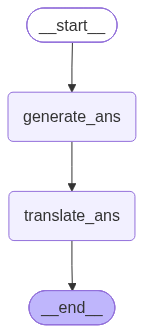

In [21]:
graph = parent_builder.compile()

graph

In [22]:
graph.invoke({'question':'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (or *quantum mechanics*) is the branch of physics that describes how matter and energy behave at the smallest scales—atoms, electrons, photons, and other sub‑atomic particles.  \nAt these scales, the classical rules of everyday physics (Newton’s laws, Maxwell’s equations) no longer apply, and the following key ideas emerge:\n\n| Concept | What it means |\n|---------|---------------|\n| **Wave‑particle duality** | Particles such as electrons can act like waves, producing interference patterns, and vice‑versa. |\n| **Quantization** | Energy, angular momentum, and other properties come in discrete “quanta” rather than a continuous range. |\n| **Superposition** | A quantum system can exist in multiple states simultaneously until measured. |\n| **Uncertainty principle** | Certain pairs of properties (e.g., position & momentum) cannot both be known precisely at the same time. |\n| **Entanglement** | Two or more parti